>0 f([-0.06595599  0.34064899]) = 0.12039
>1 f([-0.02902286  0.27948766]) = 0.07896
>2 f([-0.0129815   0.23463749]) = 0.05522
>3 f([-0.00582483  0.1993997 ]) = 0.03979
>4 f([-0.00261527  0.17071256]) = 0.02915
>5 f([-0.00117437  0.14686138]) = 0.02157
>6 f([-0.00052736  0.12676134]) = 0.01607
>7 f([-0.00023681  0.10966762]) = 0.01203
>8 f([-0.00010634  0.09503809]) = 0.00903
>9 f([-4.77542704e-05  8.24607972e-02]) = 0.00680
>10 f([-2.14444463e-05  7.16123835e-02]) = 0.00513
>11 f([-9.62980437e-06  6.22327049e-02]) = 0.00387
>12 f([-4.32434258e-06  5.41085063e-02]) = 0.00293
>13 f([-1.94188148e-06  4.70624414e-02]) = 0.00221
>14 f([-8.72017797e-07  4.09453989e-02]) = 0.00168
>15 f([-3.91586740e-07  3.56309531e-02]) = 0.00127
>16 f([-1.75845235e-07  3.10112252e-02]) = 0.00096
>17 f([-7.89647442e-08  2.69937139e-02]) = 0.00073
>18 f([-3.54597657e-08  2.34988084e-02]) = 0.00055
>19 f([-1.59234984e-08  2.04577993e-02]) = 0.00042
>20 f([-7.15057749e-09  1.78112581e-02]) = 0.00032
>21 f([-3.2

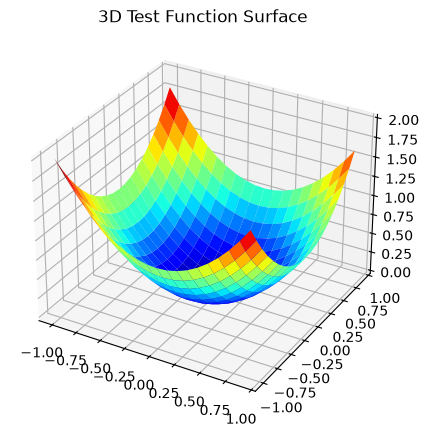

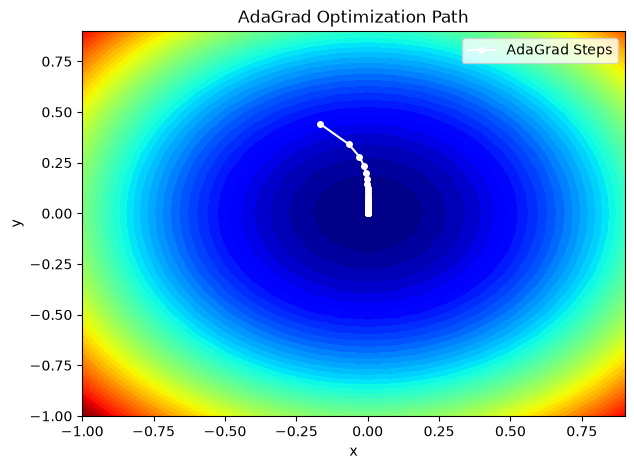

In [6]:
from math import sqrt
from numpy import asarray, arange, meshgrid
from numpy.random import rand, seed
from matplotlib import pyplot

# 1. Objective function & derivative
def objective(x, y):
    return x**2.0 + y**2.0

def derivative(x, y):
    return asarray([x * 2.0, y * 2.0])

# 2. Gradient descent algorithm with AdaGrad
def adagrad(objective, derivative, bounds, n_iter, step_size):
    # Generate an initial random point within bounds
    solution = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])
    
    # Initialize the sum of squared gradients for each variable
    sq_grad_sums = [0.0 for _ in range(bounds.shape[0])]
    trajectory = [solution]

    # Run gradient descent iterations
    for it in range(n_iter):
        # Calculate gradient
        gradient = derivative(solution[0], solution[1])
        
        # Update sum of squared partial derivatives
        for i in range(gradient.shape[0]):
            sq_grad_sums[i] += gradient[i]**2.0
            
        # Build new solution point one variable at a time
        new_solution = list()
        for i in range(solution.shape[0]):
            # Adaptive learning rate scaling
            alpha = step_size / (1e-8 + sqrt(sq_grad_sums[i]))
            value = solution[i] - alpha * gradient[i]
            new_solution.append(value)
            
        solution = asarray(new_solution)
        solution_eval = objective(solution[0], solution[1])
        trajectory.append(solution)
        
        print(f">{it} f({solution}) = {solution_eval:.5f}")

    return solution, solution_eval, asarray(trajectory)

# 3. Parameters & Execution Setup
seed(1)
bounds = asarray([[-1.0, 1.0], [-1.0, 1.0]])
n_iter = 50
step_size = 0.1

# Perform optimization
best, score, trajectory = adagrad(objective, derivative, bounds, n_iter, step_size)

print('\nOptimization Done!')
print(f'Best Solution: f({best}) = {score:.8f}')

# 4. Visualizations
# A. 3D Surface Plot
xaxis = arange(bounds[0, 0], bounds[0, 1], 0.1)
yaxis = arange(bounds[1, 0], bounds[1, 1], 0.1)
x, y = meshgrid(xaxis, yaxis)
results = objective(x, y)

figure = pyplot.figure(figsize=(7, 5))
axis = figure.add_subplot(111, projection='3d')
axis.plot_surface(x, y, results, cmap='jet')
axis.set_title("3D Test Function Surface")
pyplot.show()

# B. Filled Contour Plot with AdaGrad Trajectory
pyplot.figure(figsize=(7, 5))
pyplot.contourf(x, y, results, levels=50, cmap='jet')
pyplot.plot(trajectory[:, 0], trajectory[:, 1], '.-', color='white', markersize=8, label='AdaGrad Steps')
pyplot.title("AdaGrad Optimization Path")
pyplot.xlabel("x")
pyplot.ylabel("y")
pyplot.legend()
pyplot.show()